In this notebook, we'll make up some synthetic data, where each data point belongs to one of two classes. We'll use Fisher's linear discriminant to construct a classifier that assigns any new point $\vec{x}$ to one of the two classes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Text(0, 0.5, 'x2')

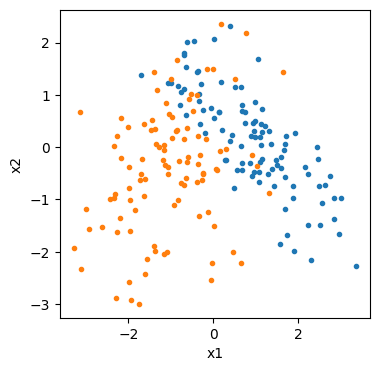

In [15]:
# Make up some two-dimensional data:
nA = 100
muA = np.array([1., 0])
sigA = np.array([[1,-0.8],[-0.8,1]])
xA = np.random.multivariate_normal(muA, sigA, nA)
nB = 100
muB = np.array([-1., -0.5])
sigB = np.array([[1,0.3],[0.3,1]])
xB = np.random.multivariate_normal(muB, sigB, nB)

# Concatenate the data:
X = np.vstack((xA, xB))  # matrix X should be n_samples by n_variables, where n_samples=nA+nB
y = np.append(np.zeros(nA), np.ones(nB))  # vector y should have length n_samples
# A label 0

# Plot the data:
plt.figure(figsize=(4,4))
plt.plot(xA[:,0], xA[:,1], '.')
plt.plot(xB[:,0], xB[:,1], '.')
plt.xlabel('x1')
plt.ylabel('x2')

## Fisher's linear discriminant

variance small as possible and groups as separated as possible
m_1 and m_2 are means of data
define hyperplane
project along w then define discriminant
covariance shared variance between a component and every other compnent 
if x is multidimensional its called covariance


In class we showed that the normal vector to the classifying hyperplane is given by
$$
\vec{w}_F \propto \mathbf{S}_W^{-1} (\vec{m}_2 - \vec{m}_1),
$$
where the "within-class" covariance is given by
$$
\mathbf{S}_W = \frac{1}{N_1}\sum_{n \in \mathcal{C}_1} (\vec{x}_n - \vec{m}_1) (\vec{x}_n - \vec{m}_1)^\top
+ \frac{1}{N_2} \sum_{n \in \mathcal{C}_2} (\vec{x}_n - \vec{m}_2) (\vec{x}_n - \vec{m}_2)^\top,
$$
and $\vec{m}_1$ and $\vec{m}_2$ are the means of the data points from class 1 and class 2, respectively.

The distance from the origin to the closest point on the hyperplane is given by 
$$
y_0 = \frac{-b + \sqrt{b^2 - 4ac}}{2a},
$$
where 
$$
\begin{align}
a &= \frac{1}{s_1^2} - \frac{1}{s_2^2} \\
b &= -2\left( \frac{m_1}{s_1^2} - \frac{m_2}{s_2^2} \right) \\
c &= \left( \frac{m_1}{s_1} \right)^2 - \left( \frac{m_2}{s_2} \right)^2 + 2 \ln \left(\frac{s_1}{s_2} \right).
\end{align}
$$

**Exercise**

Using the above expressions, calculate and plot the Fisher linear discriminant along with the synthetic data generated above. Everything should be done from scratch using only basic Numpy functions.


In [19]:
np.cov?

Signature:      
np.cov(
    m,
    y=None,
    rowvar=True,
    bias=False,
    ddof=None,
    fweights=None,
    aweights=None,
    *,
    dtype=None,
)
Call signature:  np.cov(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function cov at 0x1059b9380>
File:            /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/numpy/lib/function_base.py
Docstring:      
Estimate a covariance matrix, given data and weights.

Covariance indicates the level to which two variables vary together.
If we examine N-dimensional samples, :math:`X = [x_1, x_2, ... x_N]^T`,
then the covariance matrix element :math:`C_{ij}` is the covariance of
:math:`x_i` and :math:`x_j`. The element :math:`C_{ii}` is the variance
of :math:`x_i`.

See the notes for an outline of the algorithm.

Parameters
----------
m : array_like
    A 1-D or 2-D array containing multiple variables and observations.
    Each row of `m` represents a variable, and each column a s

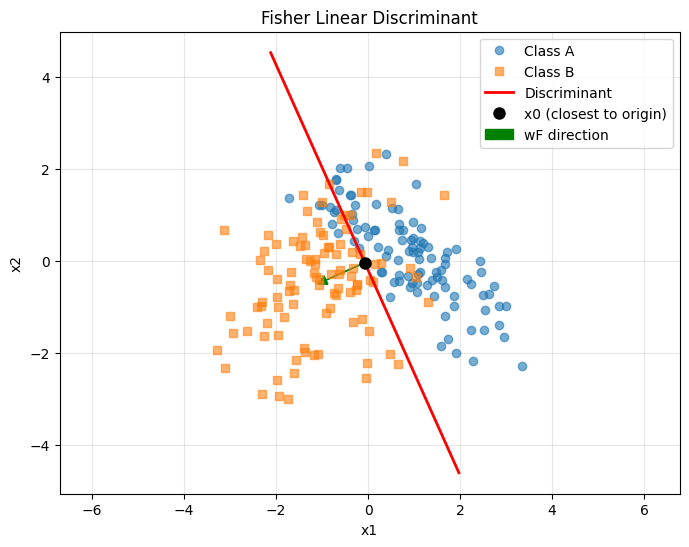

In [ ]:
## Solution ##

# Create a 2D vector wF defining the direction of the Fisher linear discriminant:
# Step 1: Compute means for each class
m1 = np.mean(xA, axis=0)  # mean of class A
m2 = np.mean(xB, axis=0)  # mean of class B
S1 = np.cov(xA, rowvar=False)  # covariance of class A
S2 = np.cov(xB, rowvar=False)  # covariance of class B

# # Step 2: Compute within-class covariance S_W
# # covariance of class A:
# S1 = np.zeros((2, 2))
# for x in xA:
#     diff = (x - m1).reshape(-1, 1)  # column vector
#     S1 += diff @ diff.T  # outer product
# S1 = S1 / nA
# # covariance of class B:
# S2 = np.zeros((2, 2))
# for x in xB:
#     diff = (x - m2).reshape(-1, 1)
#     S2 += diff @ diff.T
# S2 = S2 / nB

S_W = S1 + S2

# Step 3: Compute Fisher discriminant direction
# The optimal direction wF is given by the eigenvector of S_W^-1 (m2 - m1) with the largest eigenvalue.
# this maximizes distance between class means / variance within classes
wF = np.linalg.inv(S_W) @ (m2 - m1)
wF = wF / np.linalg.norm(wF)  # normalize to unit vector

# Determine the location of the discriminant along this vector:
# Project all data onto wF direction
yA = xA @ wF  # projections of class A
yB = xB @ wF  # projections of class B

mm1 = np.mean(yA)  # mean of projections for class A
mm2 = np.mean(yB)  # mean of projections for class B
s1 = np.std(yA)    # std of projections for class A
s2 = np.std(yB)    # std of projections for class B

a = 1/s1**2 - 1/s2**2
b = -2*(mm1/s1**2 - mm2/s2**2)
c = (mm1/s1)**2 - (mm2/s2)**2 + 2*np.log(s1/s2)
y0 = (-b + (b**2 - 4*a*c)**0.5)/(2*a)

# The point on the discriminant closest to the origin:
x0 = y0 * wF

# A vector orthogonal to wF:
wF_perp = np.array([-wF[1], wF[0]])

# Two points along the discriminant to make the line
p1 = x0 + 5 * wF_perp
p2 = x0 - 5 * wF_perp

# Plot the data with the discriminant:
plt.figure(figsize=(8, 6))
plt.plot(xA[:,0], xA[:,1], 'o', label='Class A', alpha=0.6)
plt.plot(xB[:,0], xB[:,1], 's', label='Class B', alpha=0.6)
plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'r-', linewidth=2, label='Discriminant')
plt.plot(x0[0], x0[1], 'ko', markersize=8, label='x0 (closest to origin)')
plt.arrow(0, 0, wF[0], wF[1], head_width=0.2, head_length=0.2, fc='green', ec='green', label='wF direction')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.title('Fisher Linear Discriminant')
plt.show()



**Exercise**: 

Plot a histogram showing the data projected along the direction perpendicular to the discriminant, together with the location of the discriminant itself. 


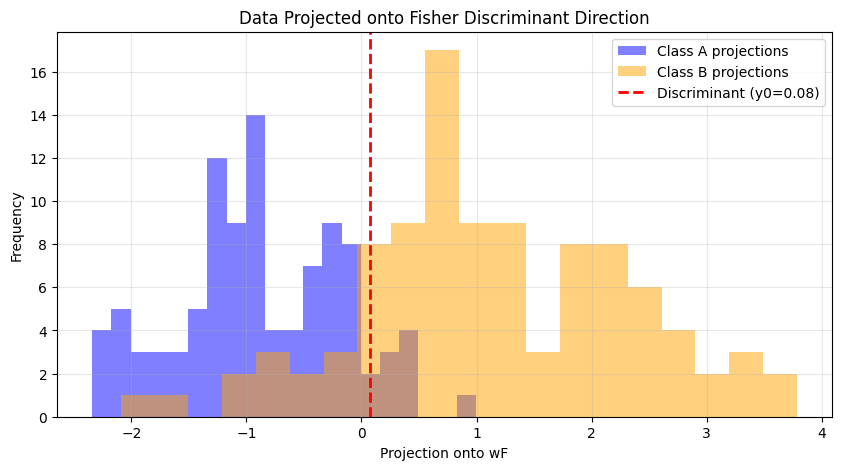

In [22]:
## Solution ##

# Plot a histogram of the data projected along wF:
plt.figure(figsize=(10, 5))
plt.hist(yA, bins=20, alpha=0.5, label='Class A projections', color='blue')
plt.hist(yB, bins=20, alpha=0.5, label='Class B projections', color='orange')
plt.axvline(y0, color='red', linestyle='--', linewidth=2, label=f'Discriminant (y0={y0:.2f})')
plt.xlabel('Projection onto wF')
plt.ylabel('Frequency')
plt.title('Data Projected onto Fisher Discriminant Direction')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Exercise**: 

Try modifying the synthetic data so that ~90% of the data belongs to one class (showing plots of this is optional) and comment on whether and why the classifier succeeds or fails for this type of unbalanced dataset.

**Solution**: 
